In [3]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers.legacy import Adam # Using legacy because it runs faster on M1 Macs
import json
import re
import gc

In [4]:
stage = "river"

### Reading and compacting dfs

In [5]:
compact = True

In [6]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir("dfs"):
    if file.endswith(".parquet"):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(f"dfs/{file}", index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = "dfs/trash"
    for f in read:
        os.rename(f"dfs/{f}", f"{trash}/{f}")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f"dfs/compacted_{timestamp}.parquet")

dfs = []  # Clear memory
raw_df

Compacintg dfs


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage,origin
0,0.000560,0.001626,0.000138,0.000900,0.000162,0.000040,0.001373,0.000785,0.001717,0.000000,...,131,21,141,True,True,True,272,1377,river,tordjes_2024-05-03_08-37-56
1,0.000917,0.001525,0.000000,0.001414,0.000207,0.001760,0.000800,0.001322,0.000600,0.001573,...,126,0,126,True,False,False,252,420,river,tordjes_2024-05-03_08-37-56
2,0.000100,0.000913,0.000000,0.001416,0.000649,0.000797,0.000000,0.000307,0.001569,0.000227,...,189,164,353,True,True,True,542,2400,river,tordjes_2024-05-03_08-37-56
3,0.000614,0.000000,0.001150,0.000326,0.001271,0.000791,0.000491,0.001559,0.000586,0.000000,...,437,0,437,True,False,False,874,1700,river,tordjes_2024-05-03_08-37-56
4,0.001522,0.001629,0.000441,0.001784,0.000141,0.000328,0.000659,0.000000,0.001797,0.000446,...,101,44,145,True,False,True,246,1497,river,tordjes_2024-05-03_08-37-56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32176,0.000994,0.000118,0.000777,0.000897,0.000554,0.001288,0.001244,0.000477,0.000000,0.000750,...,143,0,143,True,False,False,286,1531,river,tordjes_2024-05-03_04-46-30
32177,0.000228,0.001077,0.000659,0.000000,0.000000,0.001466,0.001067,0.000274,0.000256,0.000130,...,12,0,12,True,False,True,24,1368,river,tordjes_2024-05-03_04-46-30
32178,0.001446,0.001238,0.000675,0.000539,0.000487,0.001232,0.000794,0.000399,0.001773,0.001731,...,466,54,517,True,True,True,983,1465,river,tordjes_2024-05-03_04-46-30
32179,0.000699,0.001842,0.000904,0.001164,0.000849,0.000000,0.000000,0.000900,0.000061,0.001008,...,337,240,574,True,True,True,911,1621,river,tordjes_2024-05-03_04-46-30


In [7]:
# Show all types of columns:
list(sorted(set(re.sub("\\d+", "X", col) for col in raw_df.columns)))

['game_size',
 'opponent_bet_in_game',
 'opponent_bet_in_stage',
 'opponent_has_bet',
 'origin',
 'player_bet_in_game',
 'player_bet_in_stage',
 'player_has_bet',
 'player_turn',
 'pot',
 'prob_O_has_hand_X',
 'prob_P_has_hand_X',
 'public_card_X',
 'stage',
 'value_of_hand_X']

In [8]:
# Filter on stage
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage", "origin"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000560,0.001626,0.000138,0.000900,0.000162,0.000040,0.001373,0.000785,0.001717,0.000000,...,0.0,11,131,21,141,True,True,True,272,1377
1,0.000917,0.001525,0.000000,0.001414,0.000207,0.001760,0.000800,0.001322,0.000600,0.001573,...,0.0,0,126,0,126,True,False,False,252,420
2,0.000100,0.000913,0.000000,0.001416,0.000649,0.000797,0.000000,0.000307,0.001569,0.000227,...,0.0,0,189,164,353,True,True,True,542,2400
3,0.000614,0.000000,0.001150,0.000326,0.001271,0.000791,0.000491,0.001559,0.000586,0.000000,...,0.0,0,437,0,437,True,False,False,874,1700
4,0.001522,0.001629,0.000441,0.001784,0.000141,0.000328,0.000659,0.000000,0.001797,0.000446,...,0.0,0,101,44,145,True,False,True,246,1497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32176,0.000994,0.000118,0.000777,0.000897,0.000554,0.001288,0.001244,0.000477,0.000000,0.000750,...,0.0,0,143,0,143,True,False,False,286,1531
32177,0.000228,0.001077,0.000659,0.000000,0.000000,0.001466,0.001067,0.000274,0.000256,0.000130,...,0.0,0,12,0,12,True,False,True,24,1368
32178,0.001446,0.001238,0.000675,0.000539,0.000487,0.001232,0.000794,0.000399,0.001773,0.001731,...,0.0,3,466,54,517,True,True,True,983,1465
32179,0.000699,0.001842,0.000904,0.001164,0.000849,0.000000,0.000000,0.000900,0.000061,0.001008,...,0.0,3,337,240,574,True,True,True,911,1621


### Preprocessing

In [9]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.007988,0.095134,0.015251,0.102397,0.197531
1,0.000000,0.300000,0.000000,0.300000,0.600000
2,0.000000,0.078750,0.068333,0.147083,0.225833
3,0.000000,0.257059,0.000000,0.257059,0.514118
4,0.000000,0.067468,0.029392,0.096860,0.164329
...,...,...,...,...,...
32176,0.000000,0.093403,0.000000,0.093403,0.186806
32177,0.000000,0.008772,0.000000,0.008772,0.017544
32178,0.002048,0.318089,0.036860,0.352901,0.670990
32179,0.001851,0.207896,0.148057,0.354102,0.561999


In [10]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713456 0.000670357943655335
Mean and sd of range features after scaling:
-4.756716029917596e-15 1.000000000000001


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,-0.289228,1.300923,-0.919513,0.217160,-0.883194,-1.065497,0.923220,0.046218,1.436611,-1.124993,...,-1.124993,-1.124993,-1.124993,-1.124993,1.206327,-0.297697,-0.222749,-0.065128,-0.886444,0.385972
1,0.243612,1.150407,-1.124993,0.984627,-0.816049,1.500304,0.068139,0.846766,-0.229704,1.221603,...,0.376056,1.290334,1.386050,0.301777,0.838951,1.308273,-0.414556,0.753739,-0.984742,0.011128
2,-0.975311,0.236878,-1.124993,0.987011,-0.157233,0.063274,-1.124993,-0.667505,1.214948,-0.786036,...,-0.514923,0.304643,-1.012810,0.912062,-0.232321,-0.416260,0.493799,0.640433,1.341270,0.538175
3,-0.208820,-1.124993,0.591052,-0.638206,0.770462,0.054267,-0.393095,1.201305,-0.250188,-1.124993,...,-0.350305,0.969765,0.030922,-0.173685,-0.346379,0.614535,1.484391,-0.204213,0.585321,-0.814672
4,1.144850,1.305756,-0.466568,1.535848,-0.914833,-0.636205,-0.142673,-1.124993,1.556351,-0.459117,...,-1.124993,-1.124993,-1.124993,-1.124993,-0.708607,0.562042,1.529170,0.804086,0.610390,1.082270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32176,0.357370,-0.948513,0.033953,0.212939,-0.299117,0.796159,0.730514,-0.413124,-1.124993,-0.006592,...,-0.547489,0.541470,-1.124993,-0.635555,1.056758,-1.124993,-1.105704,-1.124993,1.233232,-1.124993
32177,-0.785114,0.480986,-0.142080,-1.124993,-1.124993,1.062374,0.466859,-0.716443,-0.742598,-0.931335,...,-1.124993,-0.850051,1.265415,0.811231,-1.124993,-1.124993,-1.124993,0.303598,-0.188885,-0.646615
32178,1.032704,0.722366,-0.117763,-0.321546,-0.399138,0.713265,0.059992,-0.529977,1.520275,1.457608,...,-0.790398,-0.687391,0.475128,1.184421,-0.932108,-0.946546,0.856815,0.250164,0.482245,-0.608762
32179,-0.082900,1.622369,0.223248,0.610881,0.141195,-1.124993,-1.124993,0.218067,-1.034206,0.379377,...,-0.106292,-1.012280,1.607233,-0.720608,-0.391943,-0.827817,0.254543,-1.108806,-0.801679,-1.108278


In [11]:
# Make boolean features 0 or 1
bool_columns = [
    "player_turn",
    "player_has_bet",
    "opponent_has_bet",
]


def encode_bools(df):
    df[bool_columns] = df[bool_columns].astype(int)


encode_bools(df)
df[bool_columns]

,player_turn,player_has_bet,opponent_has_bet
0,1,1,1
1,1,0,0
2,1,1,1
3,1,0,0
4,1,0,1
...,...,...,...
32176,1,0,0
32177,1,0,1
32178,1,1,1
32179,1,1,1


In [12]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,-0.289228,1.300923,-0.919513,0.217160,-0.883194,-1.065497,0.923220,0.046218,1.436611,-1.124993,...,0.0,0.0,0.007988,0.095134,0.015251,0.102397,1,1,1,0.197531
1,0.243612,1.150407,-1.124993,0.984627,-0.816049,1.500304,0.068139,0.846766,-0.229704,1.221603,...,0.0,0.0,0.000000,0.300000,0.000000,0.300000,1,0,0,0.600000
2,-0.975311,0.236878,-1.124993,0.987011,-0.157233,0.063274,-1.124993,-0.667505,1.214948,-0.786036,...,0.0,0.0,0.000000,0.078750,0.068333,0.147083,1,1,1,0.225833
3,-0.208820,-1.124993,0.591052,-0.638206,0.770462,0.054267,-0.393095,1.201305,-0.250188,-1.124993,...,0.0,0.0,0.000000,0.257059,0.000000,0.257059,1,0,0,0.514118
4,1.144850,1.305756,-0.466568,1.535848,-0.914833,-0.636205,-0.142673,-1.124993,1.556351,-0.459117,...,0.0,0.0,0.000000,0.067468,0.029392,0.096860,1,0,1,0.164329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32176,0.357370,-0.948513,0.033953,0.212939,-0.299117,0.796159,0.730514,-0.413124,-1.124993,-0.006592,...,1.0,0.0,0.000000,0.093403,0.000000,0.093403,1,0,0,0.186806
32177,-0.785114,0.480986,-0.142080,-1.124993,-1.124993,1.062374,0.466859,-0.716443,-0.742598,-0.931335,...,0.0,0.0,0.000000,0.008772,0.000000,0.008772,1,0,1,0.017544
32178,1.032704,0.722366,-0.117763,-0.321546,-0.399138,0.713265,0.059992,-0.529977,1.520275,1.457608,...,0.0,0.0,0.002048,0.318089,0.036860,0.352901,1,1,1,0.670990
32179,-0.082900,1.622369,0.223248,0.610881,0.141195,-1.124993,-1.124993,0.218067,-1.034206,0.379377,...,0.0,0.0,0.001851,0.207896,0.148057,0.354102,1,1,1,0.561999


In [13]:
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,-0.289228,1.300923,-0.919513,0.217160,-0.883194,-1.065497,0.923220,0.046218,1.436611,-1.124993,...,0.0,0.0,0.007988,0.095134,0.015251,0.102397,1,1,1,0.197531
1,0.243612,1.150407,-1.124993,0.984627,-0.816049,1.500304,0.068139,0.846766,-0.229704,1.221603,...,0.0,0.0,0.000000,0.300000,0.000000,0.300000,1,0,0,0.600000
2,-0.975311,0.236878,-1.124993,0.987011,-0.157233,0.063274,-1.124993,-0.667505,1.214948,-0.786036,...,0.0,0.0,0.000000,0.078750,0.068333,0.147083,1,1,1,0.225833
3,-0.208820,-1.124993,0.591052,-0.638206,0.770462,0.054267,-0.393095,1.201305,-0.250188,-1.124993,...,0.0,0.0,0.000000,0.257059,0.000000,0.257059,1,0,0,0.514118
4,1.144850,1.305756,-0.466568,1.535848,-0.914833,-0.636205,-0.142673,-1.124993,1.556351,-0.459117,...,0.0,0.0,0.000000,0.067468,0.029392,0.096860,1,0,1,0.164329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32176,0.357370,-0.948513,0.033953,0.212939,-0.299117,0.796159,0.730514,-0.413124,-1.124993,-0.006592,...,1.0,0.0,0.000000,0.093403,0.000000,0.093403,1,0,0,0.186806
32177,-0.785114,0.480986,-0.142080,-1.124993,-1.124993,1.062374,0.466859,-0.716443,-0.742598,-0.931335,...,0.0,0.0,0.000000,0.008772,0.000000,0.008772,1,0,1,0.017544
32178,1.032704,0.722366,-0.117763,-0.321546,-0.399138,0.713265,0.059992,-0.529977,1.520275,1.457608,...,0.0,0.0,0.002048,0.318089,0.036860,0.352901,1,1,1,0.670990
32179,-0.082900,1.622369,0.223248,0.610881,0.141195,-1.124993,-1.124993,0.218067,-1.034206,0.379377,...,0.0,0.0,0.001851,0.207896,0.148057,0.354102,1,1,1,0.561999


In [14]:
# Show all types of columns after preprocessing:
list(sorted(set(re.sub("\\d+", "X", col) for col in df.columns)))

['opponent_bet_in_game',
 'opponent_bet_in_stage',
 'opponent_has_bet',
 'player_bet_in_game',
 'player_bet_in_stage',
 'player_has_bet',
 'player_turn',
 'pot',
 'prob_O_has_hand_X',
 'prob_P_has_hand_X',
 'public_card_X',
 'value_of_hand_X']

### Data validation

In [15]:
value_columns = [col for col in df.columns if col.startswith("value_")]
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: -0.0030121420872275158
SD of target variable: 0.11235366121177497
Min of target variable: -0.8851694795585889
Max of target variable: 0.9352956194997709


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,-0.078218,-0.008647,-0.006719,-0.008777,-0.009135,-0.008356,-0.009167,-0.079328,-0.019546,0.000000,...,0.000000,0.000000,0.000000,0.000000,-0.059397,-0.092338,-0.074502,-0.061093,-0.089241,-0.075613
1,0.077846,0.081059,0.000000,-0.011370,-0.004840,0.043243,0.028047,0.019256,0.010436,-0.007999,...,0.003321,-0.008986,-0.011057,-0.022410,-0.009170,-0.012289,-0.023679,-0.009510,-0.009631,-0.024989
2,0.062939,0.062639,0.000000,0.061824,0.061671,0.063440,0.000000,-0.015034,-0.029237,-0.056457,...,-0.029789,-0.056574,-0.087108,-0.131525,-0.057245,-0.087446,-0.131855,-0.086984,-0.131156,-0.132232
3,-0.013213,0.000000,0.066491,0.064438,0.061378,-0.040269,0.054344,0.044054,0.032081,0.000000,...,0.019303,-0.034951,0.001634,-0.027401,-0.034729,-0.000539,-0.032315,-0.036230,-0.036914,-0.039765
4,0.055078,0.055299,0.054984,-0.005243,-0.048859,-0.013068,-0.023803,0.000000,0.053706,0.051974,...,0.000000,0.000000,0.000000,0.000000,-0.056117,0.048295,0.017867,0.045384,0.012995,0.013159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32176,0.017773,0.027234,0.016496,0.013477,0.009779,0.004547,-0.001893,-0.004649,0.000000,-0.008582,...,-0.018409,-0.008656,0.000000,-0.013723,-0.018425,0.000000,-0.018494,0.000000,-0.013739,0.000000
32177,0.007706,0.007729,0.007758,0.000000,0.000000,0.001049,-0.000164,-0.000448,-0.000733,-0.001730,...,0.000000,-0.001775,-0.002481,-0.001061,0.000000,0.000000,0.000000,-0.000030,-0.001154,-0.001172
32178,0.476743,-0.101092,0.453487,0.419058,-0.166079,-0.221629,0.372711,0.303721,0.205918,0.089606,...,0.155292,0.036959,-0.296684,-0.090686,0.023145,-0.294865,-0.104069,-0.298575,-0.059229,-0.305529
32179,0.376278,0.373699,0.375537,0.375473,0.374167,0.000000,0.000000,-0.127844,0.212842,0.103482,...,-0.151732,-0.153116,-0.280133,-0.293181,-0.323831,-0.203842,-0.252392,-0.204275,-0.253102,-0.297002


In [16]:
# Remove any rows with target values outside [-1, 1]
df = df[(df[value_columns] >= -1).all(axis=1) & (df[value_columns] <= 1).all(axis=1)]
print("After removing outliers:")
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())

After removing outliers:
Mean of target variable: -0.0030121420872275158
SD of target variable: 0.11235366121177497
Min of target variable: -0.8851694795585889
Max of target variable: 0.9352956194997709


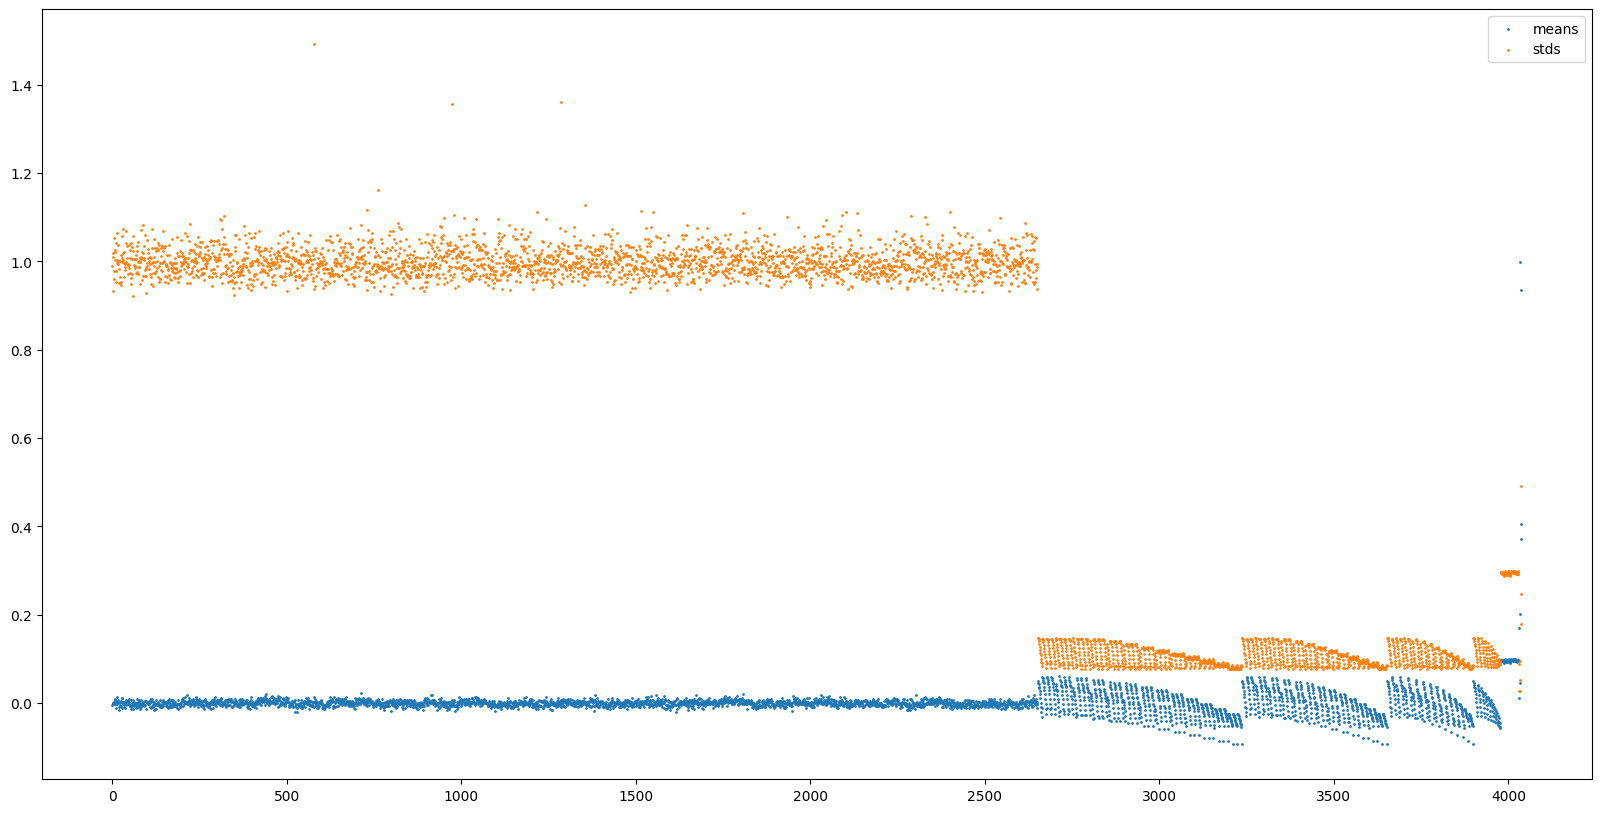

In [17]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means", s=1)
plt.scatter(range(df.std().size), df.std(), label="stds", s=1)
plt.legend()
plt.show()

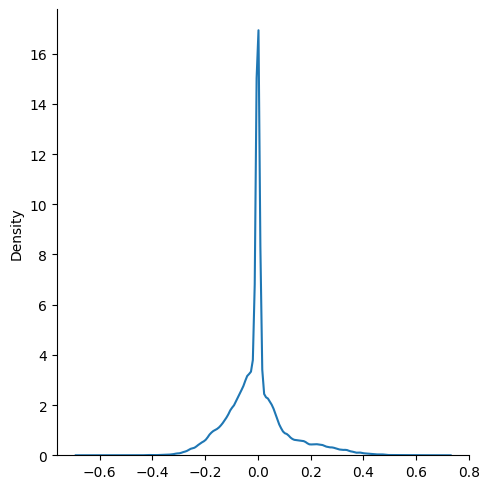

In [18]:
# Plot distribution of target values in a bell curve
from seaborn import displot

# Sample 1000 rows to speed up plotting
displot(df[value_columns].sample(1000).to_numpy().flatten(), kind="kde")
plt.show()

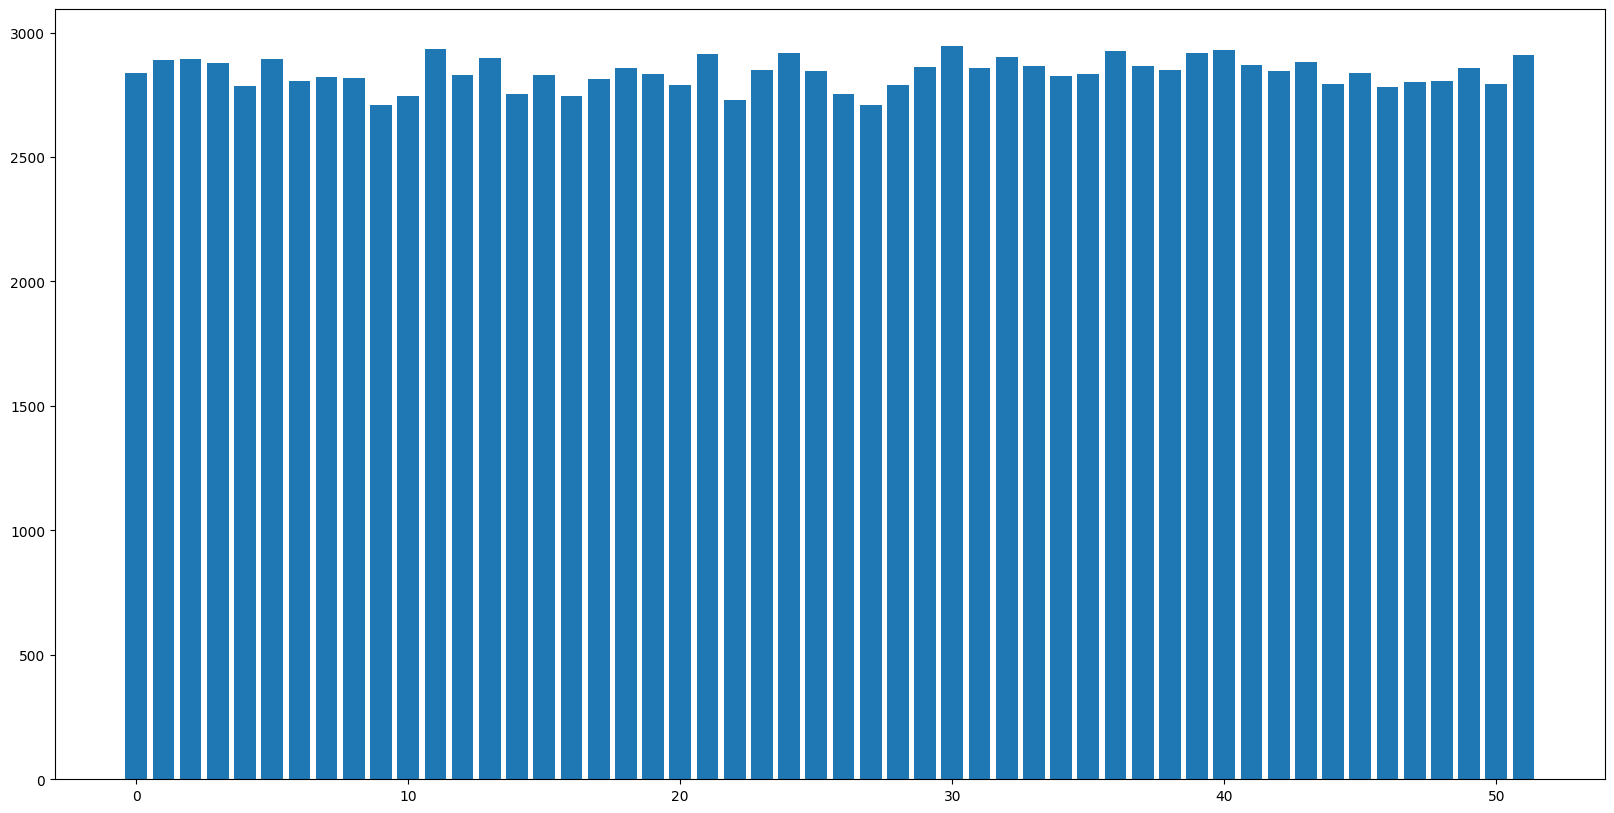

In [19]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_") and "*" not in col]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

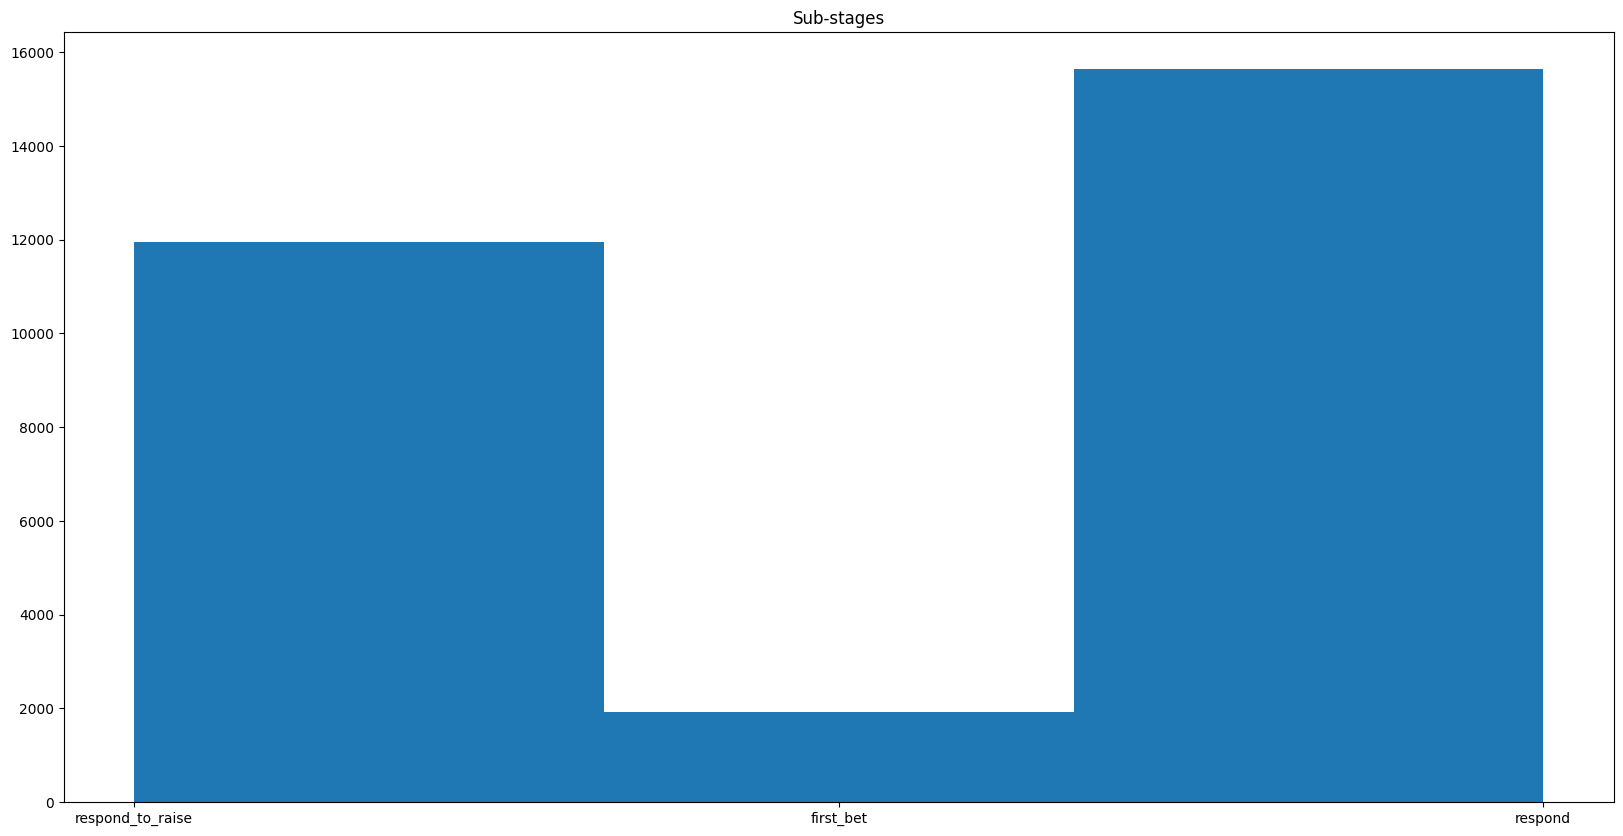

In [20]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [21]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(29522, 2712) (29522, 1326)


### Structure for Neural Network

In [22]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [26]:
def generate_model(l1_rate=1e-9, l2_rate=1e-8):
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define a small standard deviation for the initial weights
    init = RandomNormal(mean=0.0, stddev=0.002, seed=42)

    # Only use one hidden layer for now because we have so little data
    hidden_layer_1 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_1",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(input_layer)

    hidden_layer_2 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_2",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_1)

    hidden_layer_3 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_3",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_2)

    # Add a dropout layer to prevent overfitting
    # dropout_layer = Dropout(0.5)(hidden_layer_3)

    # Define output layer
    value_layer_P1 = Dense(
        Y.shape[1],
        activation="linear",
        name="value_layer_P1",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_3)

    # Naturally, the target variable is centered around 0 with a SD of ~0.1, thus
    # to get an SD of 1, it is scaled by 10. To make this scaling implicit in the model,
    # rather than having to do it in the preprocessing, we add a scaling layer here.
    scaling_layer = Lambda(lambda x: x * 10)(value_layer_P1)

    # Create an Adam optimizer with a small learning rate
    small_lr_optimizer = Adam(learning_rate=0.000001)

    # Create model
    model = Model(inputs=input_layer, outputs=scaling_layer)
    model.compile(optimizer=small_lr_optimizer, loss="mean_squared_error")

    return model

### Split data

In [27]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### Cross validation

In [28]:
# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []
validation_predictions = []
validation_actuals = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

folds = list(kf.split(X_train))
# folds = folds[:1] # Limit the number of folds to look at

# Loop over each fold
for i, (train_index, val_index) in enumerate(folds):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)
    validation_predictions.append(model.predict(X_val_fold))
    validation_actuals.append(Y_val_fold)

@@@ FOLD 1 @@@
Size of training set: 18893
Epoch 1/1000


2024-05-03 14:58:17.759692: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


591/591 [==============================] - ETA: 0s - loss: 0.0122

2024-05-03 15:00:50.076913: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


591/591 [==============================] - 160s 268ms/step - loss: 0.0122 - val_loss: 0.0114
Epoch 2/1000
591/591 [==============================] - 157s 265ms/step - loss: 0.0099 - val_loss: 0.0092
Epoch 3/1000
591/591 [==============================] - 163s 276ms/step - loss: 0.0088 - val_loss: 0.0088
Epoch 4/1000
591/591 [==============================] - 160s 270ms/step - loss: 0.0084 - val_loss: 0.0086
Epoch 5/1000
591/591 [==============================] - 160s 270ms/step - loss: 0.0082 - val_loss: 0.0085
Epoch 6/1000
591/591 [==============================] - 162s 273ms/step - loss: 0.0081 - val_loss: 0.0084
Epoch 7/1000
591/591 [==============================] - 161s 273ms/step - loss: 0.0080 - val_loss: 0.0084
Epoch 8/1000
591/591 [==============================] - 162s 275ms/step - loss: 0.0079 - val_loss: 0.0084
Epoch 9/1000
591/591 [==============================] - 166s 281ms/step - loss: 0.0079 - val_loss: 0.0084
Epoch 10/1000
591/591 [==============================] - 16

2024-05-03 15:35:56.444485: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


148/148 [==============================] - 2s 15ms/step
@@@ FOLD 2 @@@
Size of training set: 18893
Epoch 1/1000


2024-05-03 15:36:02.791897: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


557/591 [===========================>..] - ETA: 9s - loss: 0.0124

KeyboardInterrupt: 

In [29]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history["val_loss"]
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
baseline_mse = np.mean((Y_test - np.mean(Y_train, axis=0)) ** 2)
print(f"Baseline MSE: {baseline_mse:.4f}")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Cross-Validation MSE: 0.0085 (+/- 0.0000)
Baseline MSE: 0.0118
Cross-Validation RMSE: 0.0920 (+/- 0.0000)
Baseline RMSE: 0.1084


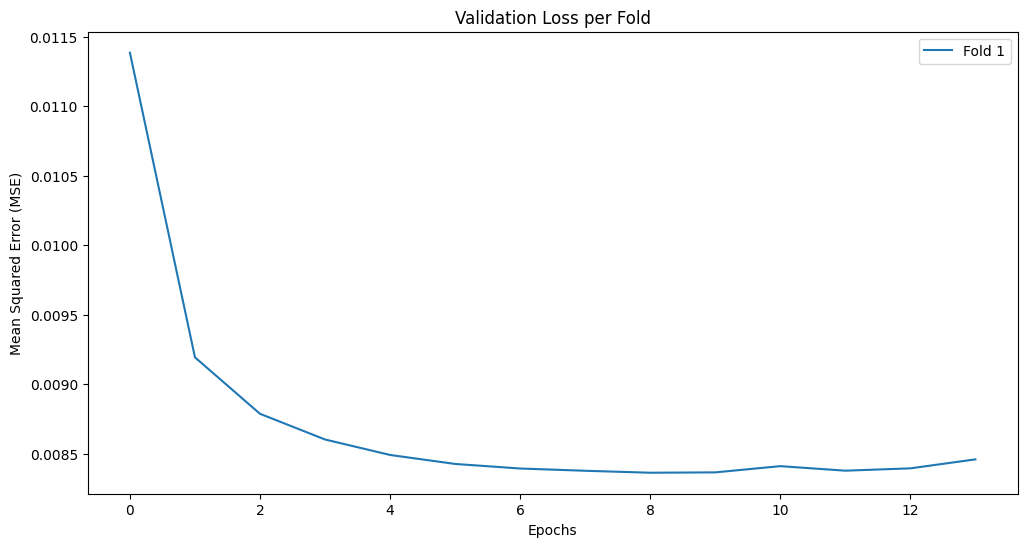

In [30]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

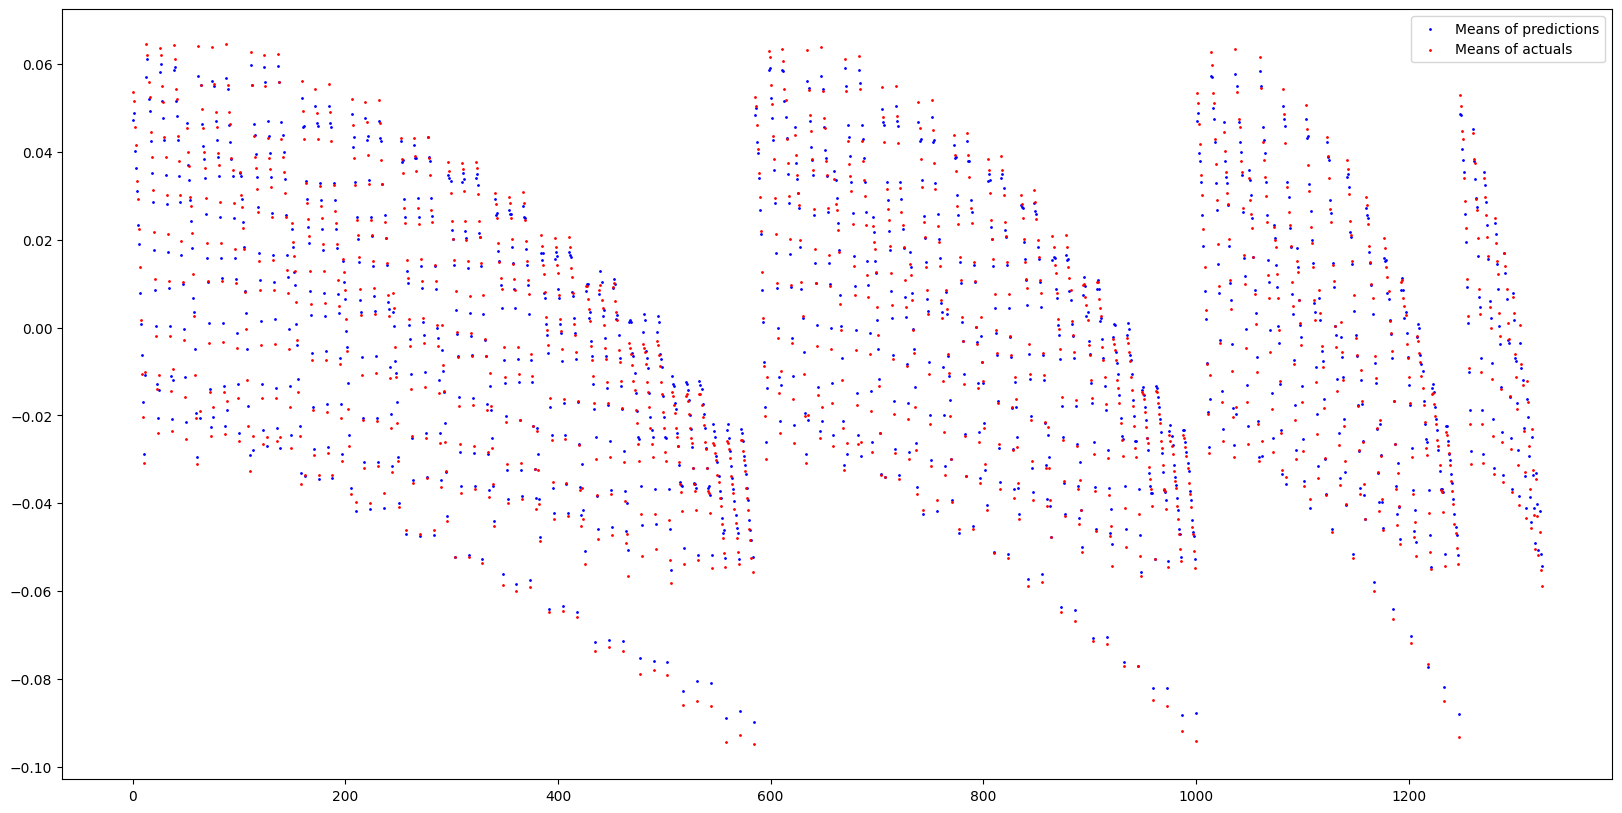

In [31]:
# Plot the distribution of outputs from the model
Y_val_pred = np.concatenate(validation_predictions)
Y_val = np.concatenate(validation_actuals)
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(
    range(Y_val_pred.mean(axis=0).size),
    Y_val_pred.mean(axis=0),
    label="Means of predictions",
    s=1,
    c="blue",
)
plt.scatter(
    range(Y_val.mean(axis=0).size),
    Y_val.mean(axis=0),
    label="Means of actuals",
    s=1,
    c="red",
)
plt.legend()
plt.show()

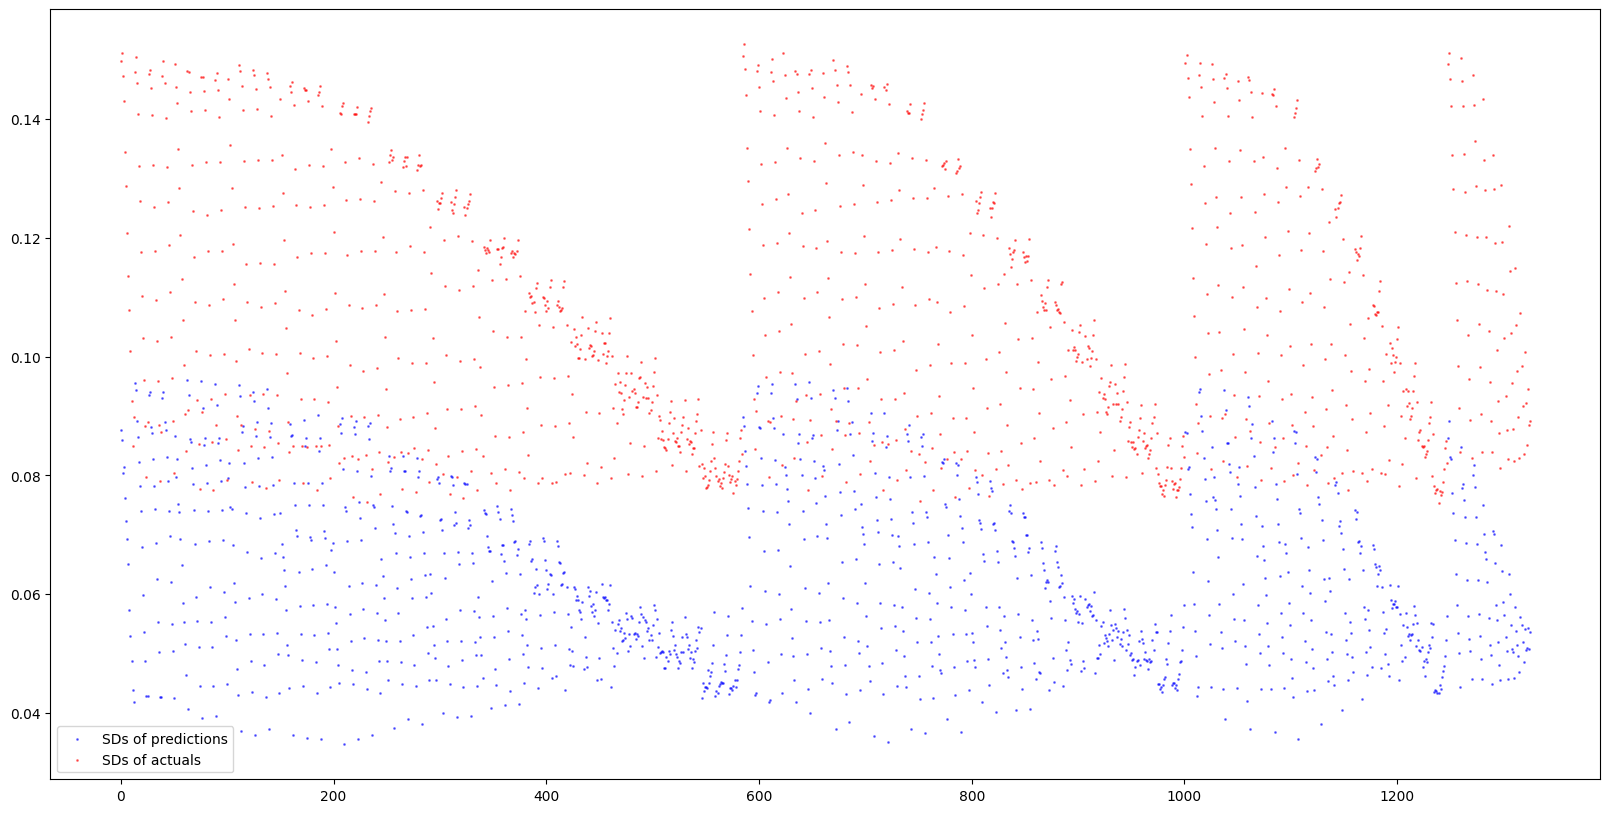

In [32]:
# Plot the distribution of outputs from the model
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(
    range(Y_val_pred.std(axis=0).size),
    Y_val_pred.std(axis=0),
    label="SDs of predictions",
    s=1,
    c="blue",
    alpha=0.5,
)
plt.scatter(
    range(Y_val.std(axis=0).size),
    Y_val.std(axis=0),
    label="SDs of actuals",
    s=1,
    c="red",
    alpha=0.5,
)
plt.legend()
plt.show()

In [33]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
final_epoch_number = int(average_optimal_epoch)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 8


In [29]:
# Clear memory
fold_results = []
gc.collect()

15137

### Testing

In [30]:
# Test the model
model = generate_model()
epochs = final_epoch_number
model.fit(X_train, Y_train, epochs=epochs)
test_loss = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

Epoch 1/32


2024-05-03 11:16:05.006179: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


590/590 [==============================] - 35s 59ms/step - loss: 0.0128
Epoch 2/32
590/590 [==============================] - 34s 57ms/step - loss: 0.0119
Epoch 3/32
590/590 [==============================] - 34s 57ms/step - loss: 0.0110
Epoch 4/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0102
Epoch 5/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0095
Epoch 6/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0091
Epoch 7/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0090
Epoch 8/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0089
Epoch 9/32
590/590 [==============================] - 36s 60ms/step - loss: 0.0088
Epoch 10/32
590/590 [==============================] - 35s 60ms/step - loss: 0.0088
Epoch 11/32
590/590 [==============================] - 36s 61ms/step - loss: 0.0087
Epoch 12/32
590/590 [==============================] - 36s 61ms/step - loss: 0.0087
Epoch 13/32


2024-05-03 11:34:50.190176: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


148/148 [==============================] - 3s 17ms/step - loss: 0.0089
Test MSE: 0.0089
Test RMSE: 0.0941


In [33]:
# As a baseline, calculate the RMSE of predicting only zeros
baseline_mse = np.mean(Y_test**2)
print(f"Baseline MSE: {baseline_mse:.4f}")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MSE: 0.0129
Baseline RMSE: 0.1136


In [34]:
# As a better baseline, calculate the RMSE of predicting the mean of the target variable
mean_target = np.mean(Y_train, axis=0)
mean_baseline_mse = np.mean((Y_test - mean_target)**2)
print(f"Mean Baseline MSE: {mean_baseline_mse:.4f}")
mean_baseline_rmse = np.sqrt(mean_baseline_mse)
print(f"Mean Baseline RMSE: {mean_baseline_rmse:.4f}")

Mean Baseline MSE: 0.0119
Mean Baseline RMSE: 0.1092


In [ ]:
# Clear memory
model = None
gc.collect()

3141

### Training of final model

In [ ]:
# Train model on all data
model = generate_model()
model.fit(X, Y, epochs=epochs)

# Change working directory to models
os.chdir("models")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
model_fname = f"model_{stage}_{timestamp}.h5"
model.save(model_fname)

# Save metadata
metadata = {
    "mean_training_range_val": mean_training_range_val,
    "sd_training_range_val": sd_training_range_val,
}
meta_fname = f"model_{stage}_{timestamp}.json"
with open(meta_fname, "w") as f:
    json.dump(metadata, f)

# Symlink the model to the latest model
latest_fname = f"model_{stage}_latest.h5"
latest_meta_fname = f"model_{stage}_latest.json"
if os.path.exists(latest_fname):
    os.remove(latest_fname)
if os.path.exists(latest_meta_fname):
    os.remove(latest_meta_fname)
os.symlink(model_fname, latest_fname)
os.symlink(meta_fname, latest_meta_fname)

# Change working directory back to parent
os.chdir("..")

Epoch 1/396
 1/10 [==>...........................] - ETA: 2s - loss: 0.0447

2024-05-01 21:27:46.969824: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


10/10 [==============================] - 1s 41ms/step - loss: 0.0462
Epoch 2/396
10/10 [==============================] - 0s 30ms/step - loss: 0.0422
Epoch 3/396
10/10 [==============================] - 0s 30ms/step - loss: 0.0391
Epoch 4/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0366
Epoch 5/396
10/10 [==============================] - 0s 36ms/step - loss: 0.0346
Epoch 6/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0326
Epoch 7/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0312
Epoch 8/396
10/10 [==============================] - 0s 32ms/step - loss: 0.0299
Epoch 9/396
10/10 [==============================] - 0s 30ms/step - loss: 0.0289
Epoch 10/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0278
Epoch 11/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0270
Epoch 12/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0262
Epoch 13/396
10/10 [=================

/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Load model
model = tf.keras.models.load_model(f"models/{latest_fname}")
gc.collect()

786

In [ ]:
# Test making a point prediction
X_test_point = X_test[0].reshape(1, -1)
Y_test_point = Y_test[0].reshape(1, -1)
print("X_test_point shape:", X_test_point.shape)
Y_pred_point = model.predict(X_test_point)
print("Test point prediction:")
print("Actual:", Y_test_point)
print("Predicted:", Y_pred_point)

X_test_point shape: (1, 2712)
1/1 [==============================] - 0s 31ms/step
Test point prediction:
Actual: [[ 0.04335213  0.04521447  0.07330771 ...  0.00545103 -0.01149098
  -0.0120648 ]]
Predicted: [[ 0.0455304   0.04117741  0.07303078 ...  0.0120005  -0.00112417
  -0.00029863]]


2024-05-01 21:30:03.769883: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
